In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [13]:
transcriptomics_path = "../data/raw/OmicsExpressionProteinCodingGenesTPMLogp1.csv"
transcriptomics = pd.read_csv(transcriptomics_path, index_col=0)
transcriptomics.index.name = "DepMap_ID"
transcriptomics.columns = transcriptomics.columns.str.replace(
    r"\s*\(\d+\)\s*", "", regex=True
)

metabolomics_path = "../data/raw/CCLE_metabolomics_20190502.csv"
metabolomics = pd.read_csv(metabolomics_path)
metabolomics = metabolomics.set_index("DepMap_ID")
metabolomics = metabolomics.drop(columns=["CCLE_ID"])

In [14]:
# Transcriptomics
gene_var = transcriptomics.var(axis=0)
transcriptomics = transcriptomics.loc[:, gene_var >= 0.05]

sample_sum_tx = transcriptomics.sum(axis=1)
outlier_mask_tx = np.abs(stats.zscore(sample_sum_tx)) > 3
trans_clean = transcriptomics[~outlier_mask_tx]

# Metabolomics
sample_sum_meta = metabolomics.sum(axis=1)
outlier_mask_meta = np.abs(stats.zscore(sample_sum_meta)) > 3
meta_clean = metabolomics[~outlier_mask_meta]

# Joined
paired = trans_clean.join(meta_clean, how="inner")
trans_paired = paired[trans_clean.columns]
meta_paired = paired[meta_clean.columns]

print(f"Paired N: {paired.shape[0]}")
print(f"Transcriptomics features: {trans_paired.shape[1]}")
print(f"Metabolomics features: {meta_paired.shape[1]}")

Paired N: 898
Transcriptomics features: 17384
Metabolomics features: 225


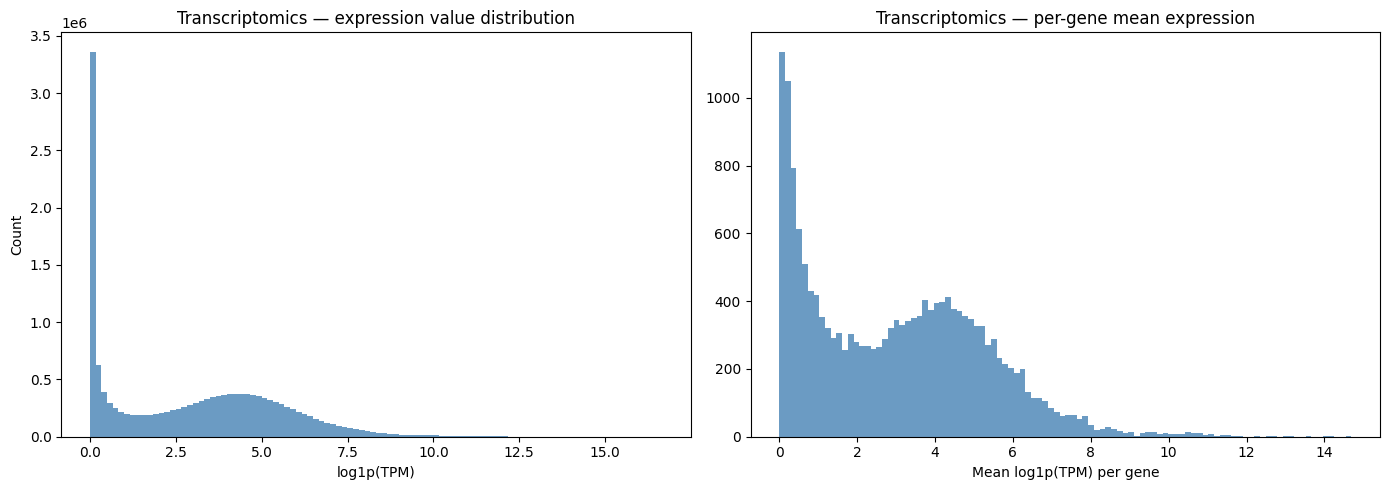

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(trans_paired.values.flatten(), bins=100, color="steelblue", alpha=0.8)
axes[0].set_xlabel("log1p(TPM)")
axes[0].set_ylabel("Count")
axes[0].set_title("Transcriptomics — expression value distribution")

axes[1].hist(trans_paired.mean(axis=0), bins=100, color="steelblue", alpha=0.8)
axes[1].set_xlabel("Mean log1p(TPM) per gene")
axes[1].set_title("Transcriptomics — per-gene mean expression")

plt.tight_layout()
plt.savefig("../reports/dist_transcriptomics.png", dpi=150)
plt.show()

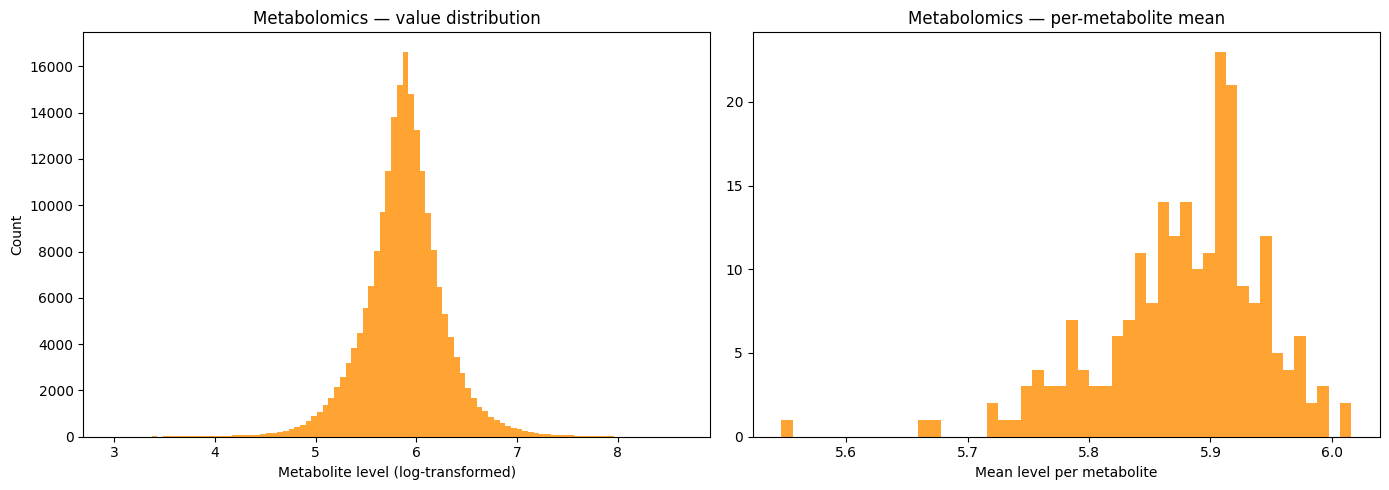

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(meta_paired.values.flatten(), bins=100, color="darkorange", alpha=0.8)
axes[0].set_xlabel("Metabolite level (log-transformed)")
axes[0].set_ylabel("Count")
axes[0].set_title("Metabolomics — value distribution")

axes[1].hist(meta_paired.mean(axis=0), bins=50, color="darkorange", alpha=0.8)
axes[1].set_xlabel("Mean level per metabolite")
axes[1].set_title("Metabolomics — per-metabolite mean")

plt.tight_layout()
plt.savefig("../reports/dist_metabolomics.png", dpi=150)
plt.show()

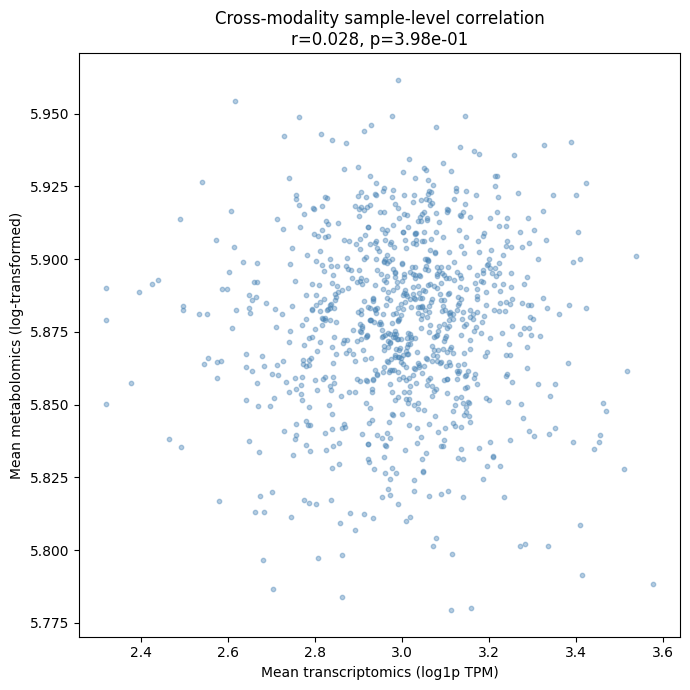

Pearson r: 0.028, p-value: 3.98e-01


In [20]:
trans_sample_mean = trans_paired.mean(axis=1)
meta_sample_mean = meta_paired.mean(axis=1)

r, p = stats.pearsonr(trans_sample_mean, meta_sample_mean)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(trans_sample_mean, meta_sample_mean, alpha=0.4, s=10, color="steelblue")
ax.set_xlabel("Mean transcriptomics (log1p TPM)")
ax.set_ylabel("Mean metabolomics (log-transformed)")
ax.set_title(f"Cross-modality sample-level correlation\nr={r:.3f}, p={p:.2e}")
plt.tight_layout()
plt.savefig("../reports/correlation_cross_modality.png", dpi=150)
plt.show()

print(f"Pearson r: {r:.3f}, p-value: {p:.2e}")

In [21]:
pairs_to_check = [
    ("PHGDH", "3-phosphoglycerate"),
    ("LDHA", "aconitate"),
    ("GOT1", "aconitate"),
    ("SHMT2", "3-phosphoglycerate"),
]

for gene, metabolite in pairs_to_check:
    if gene in trans_paired.columns and metabolite in meta_paired.columns:
        r, p = stats.pearsonr(trans_paired[gene], meta_paired[metabolite])
        print(f"{gene} vs {metabolite}: r={r:.3f}, p={p:.3e}")
    else:
        print(f"{gene} or {metabolite} not found in data")

PHGDH vs 3-phosphoglycerate: r=-0.021, p=5.339e-01
LDHA vs aconitate: r=0.124, p=1.965e-04
GOT1 vs aconitate: r=0.030, p=3.687e-01
SHMT2 vs 3-phosphoglycerate: r=-0.155, p=3.206e-06


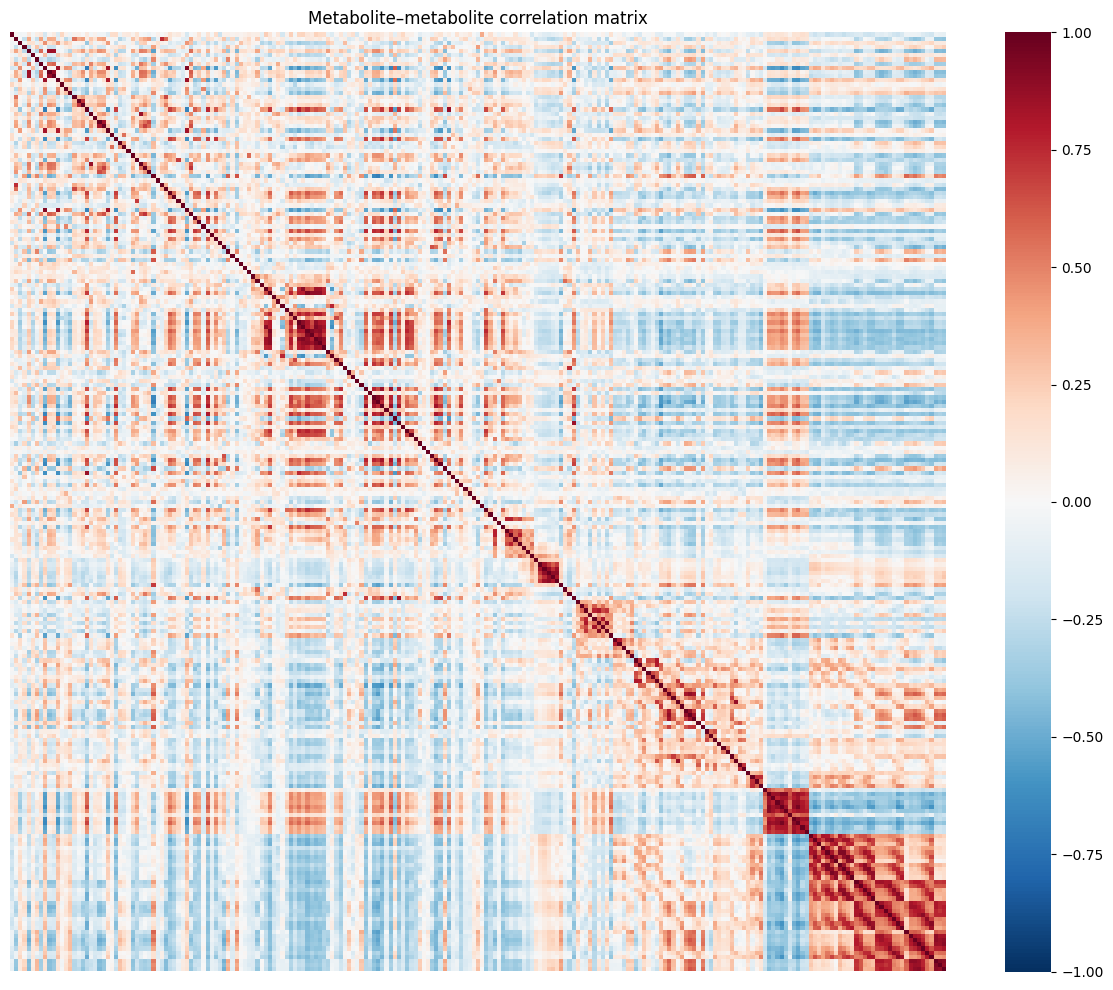

In [22]:
meta_corr = meta_paired.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(meta_corr, cmap="RdBu_r", center=0, ax=ax,
            xticklabels=False, yticklabels=False, vmin=-1, vmax=1)
ax.set_title("Metabolite–metabolite correlation matrix")
plt.tight_layout()
plt.savefig("../reports/correlation_metabolites.png", dpi=150)
plt.show()

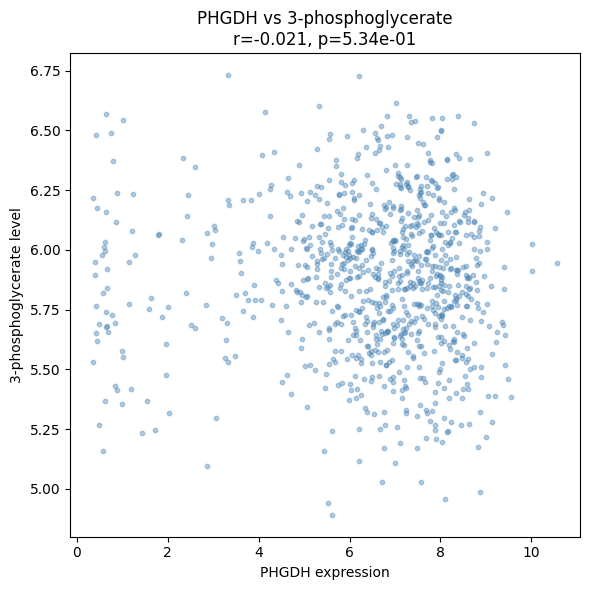

In [23]:
gene = "PHGDH"
metabolite = "3-phosphoglycerate"

if gene in trans_paired.columns and metabolite in meta_paired.columns:
    r, p = stats.pearsonr(trans_paired[gene], meta_paired[metabolite])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(trans_paired[gene], meta_paired[metabolite],
               alpha=0.4, s=10, color="steelblue")
    ax.set_xlabel(f"{gene} expression")
    ax.set_ylabel(f"{metabolite} level")
    ax.set_title(f"{gene} vs {metabolite}\nr={r:.3f}, p={p:.2e}")
    plt.tight_layout()
    plt.savefig(f"../reports/correlation_{gene}_{metabolite}.png", dpi=150)
    plt.show()

In [25]:
try:
    model_meta = pd.read_csv("../data/raw/Model.csv", index_col=0)
    cancer_types = model_meta["OncotreeLineage"].reindex(paired.index)
    print(f"Cancer type labels loaded: {cancer_types.nunique()} unique lineages")
except FileNotFoundError:
    print("Model.csv not found — PCA will be uncolored")
    cancer_types = None

Cancer type labels loaded: 25 unique lineages


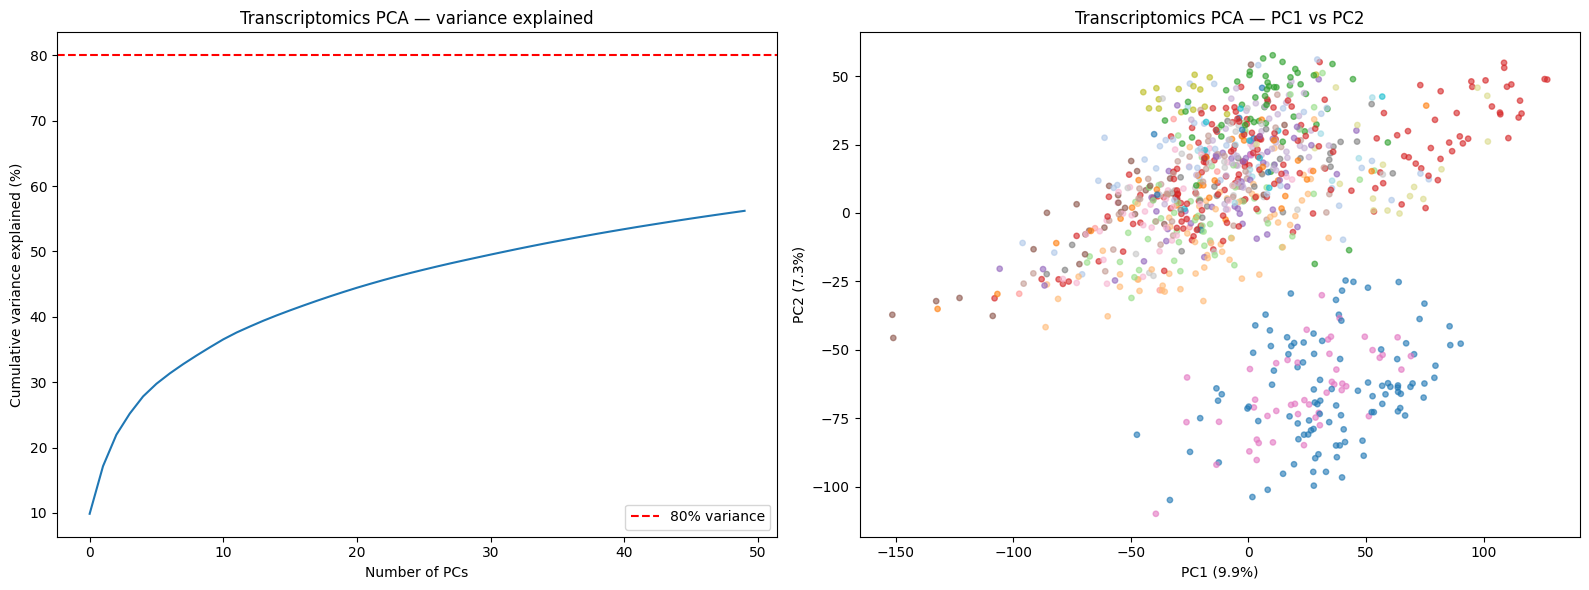

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
trans_scaled = scaler.fit_transform(trans_paired)

pca_trans = PCA(n_components=50)
trans_pcs = pca_trans.fit_transform(trans_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# variance explained
axes[0].plot(np.cumsum(pca_trans.explained_variance_ratio_) * 100)
axes[0].axhline(80, color="red", linestyle="--", label="80% variance")
axes[0].set_xlabel("Number of PCs")
axes[0].set_ylabel("Cumulative variance explained (%)")
axes[0].set_title("Transcriptomics PCA — variance explained")
axes[0].legend()

# PC1 vs PC2
if cancer_types is not None:
    unique_types = cancer_types.dropna().unique()
    palette = dict(zip(unique_types, sns.color_palette("tab20", len(unique_types))))
    colors = cancer_types.map(palette).fillna("grey")
    axes[1].scatter(trans_pcs[:, 0], trans_pcs[:, 1],
                    c=colors, alpha=0.6, s=15)
else:
    axes[1].scatter(trans_pcs[:, 0], trans_pcs[:, 1], alpha=0.6, s=15)

axes[1].set_xlabel(f"PC1 ({pca_trans.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_trans.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Transcriptomics PCA — PC1 vs PC2")

plt.tight_layout()
plt.savefig("../reports/pca_transcriptomics.png", dpi=150)
plt.show()

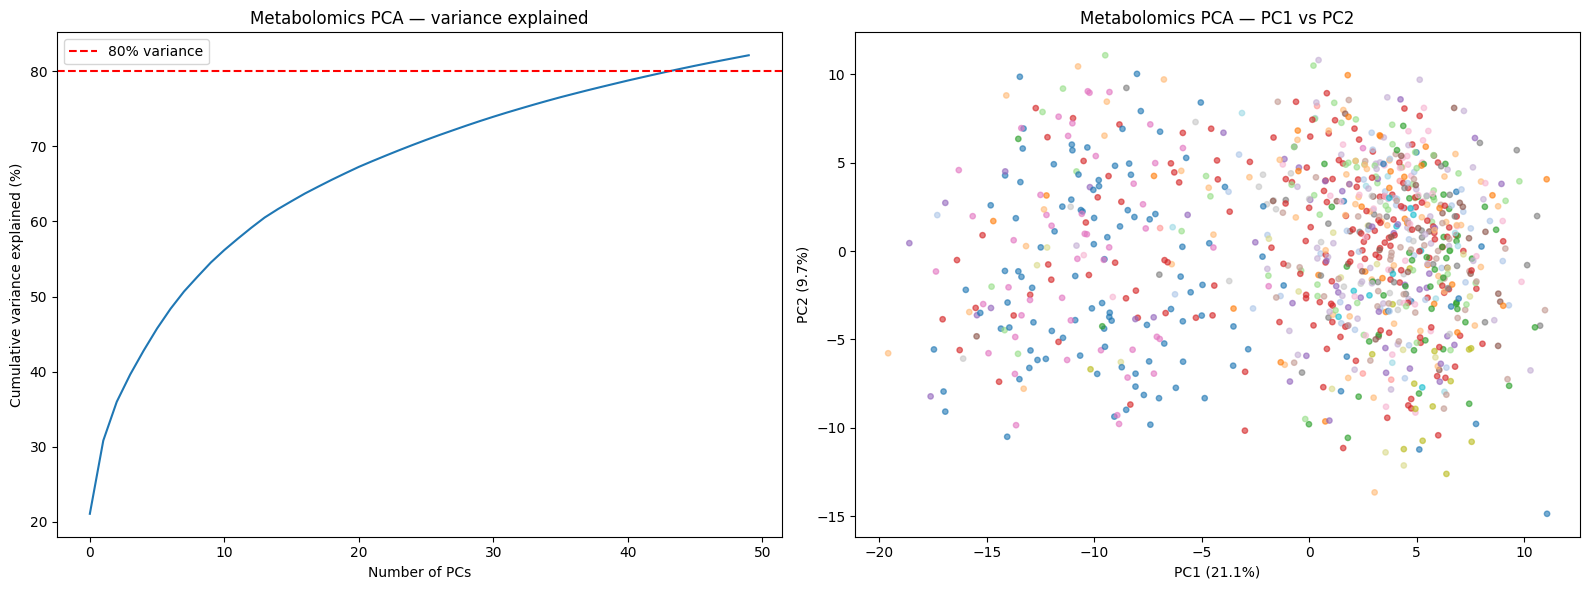

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
meta_scaled = scaler.fit_transform(meta_paired)

pca_meta = PCA(n_components=50)
meta_pcs = pca_meta.fit_transform(meta_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# variance explained
axes[0].plot(np.cumsum(pca_meta.explained_variance_ratio_) * 100)
axes[0].axhline(80, color="red", linestyle="--", label="80% variance")
axes[0].set_xlabel("Number of PCs")
axes[0].set_ylabel("Cumulative variance explained (%)")
axes[0].set_title("Metabolomics PCA — variance explained")
axes[0].legend()

# PC1 vs PC2
if cancer_types is not None:
    unique_types = cancer_types.dropna().unique()
    palette = dict(zip(unique_types, sns.color_palette("tab20", len(unique_types))))
    colors = cancer_types.map(palette).fillna("grey")
    axes[1].scatter(meta_pcs[:, 0], meta_pcs[:, 1],
                    c=colors, alpha=0.6, s=15)
else:
    axes[1].scatter(meta_pcs[:, 0], meta_pcs[:, 1], alpha=0.6, s=15)

axes[1].set_xlabel(f"PC1 ({pca_meta.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_meta.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Metabolomics PCA — PC1 vs PC2")

plt.tight_layout()
plt.savefig("../reports/pca_metabolomics.png", dpi=150)
plt.show()